# Exercise: Navigating FrozenLake-v1
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Read and use a standard Gymnasium environment (`reset` / `step` / spaces)
- Implement the Q-learning update
- Train an agent under a **sparse** reward and evaluate it honestly
- Apply the result to pathfinding

## Real-World Context

Navigation under uncertainty — warehouse robots, delivery routing, game AI. You will work on
`FrozenLake-v1`, the environment used in the Gymnasium documentation and in countless tutorials and
papers, so the interface you learn here is the one you will meet again.

**Task**: Build a Q-learning agent that reaches the goal tile.

---

## Task 1: The Environment (25 points)

Instead of writing your own grid class, load the standard benchmark and read it properly:

1. Create the environment and print its observation and action spaces
2. Print the map and work out which tile index each square has
3. Take one `step()` and identify all five values it returns
4. State the reward rule in one sentence, and say why it is called **sparse**

## Exercise Brief

This exercise checks whether students can implement the full Q-learning loop themselves.

They must connect environment interaction, action selection, value updates, and learning progress into one coherent workflow.

Why this matters: Unit 2 is where RL stops being only conceptual and starts becoming algorithmic.

This exercise verifies that students can translate the lesson into runnable logic.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Exercise Goal

Build a small grid-world Q-learning setup and explain why the learned values should
improve navigation toward the goal.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Task 1 setup: open the STANDARD navigation benchmark instead of hand-building a grid.
# WHY it matters: FrozenLake-v1 is the environment used in the Gymnasium docs, in tutorials and in
# papers. Learning its interface (reset / step / observation_space / action_space) is the skill that
# transfers - a grid class written for one exercise is not.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# is_slippery=False keeps the moves deterministic so Task 3 converges quickly.
# The stretch task at the end asks you to switch it on.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n
layout = env.unwrapped.desc.astype(str)

print("Environment :", env.spec.id)
print("States      :", n_states, "(tile index 0-15, counted left-to-right, top-to-bottom)")
print("Actions     :", n_actions, "(0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)")
print("\nThe map (S=start, F=frozen, H=hole, G=goal):")
for row in layout:
    print("   " + " ".join(row))

# The gym loop every RL project uses. reset() gives the first state; step() returns five things.
state, info = env.reset(seed=0)
print(f"\nreset() -> starting state {state}")
next_state, reward, terminated, truncated, info = env.step(2)   # try one step to the RIGHT
print(f"step(2 = RIGHT) -> state {next_state}, reward {reward}, "
      f"terminated {terminated}, truncated {truncated}")
print("\nReward rule: 1.0 ONLY for reaching the goal tile. Every other step scores 0.0.")
print("That is a SPARSE reward - the hard case, and the reason exploration matters here.")

Environment : FrozenLake-v1
States      : 16 (tile index 0-15, counted left-to-right, top-to-bottom)
Actions     : 4 (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)

The map (S=start, F=frozen, H=hole, G=goal):
   S F F F
   F H F H
   F F F H
   H F F G

reset() -> starting state 0
step(2 = RIGHT) -> state 1, reward 0, terminated False, truncated False

Reward rule: 1.0 ONLY for reaching the goal tile. Every other step scores 0.0.
That is a SPARSE reward - the hard case, and the reason exploration matters here.


## Task 2: Q-Learning Implementation (35 points)

Implement Q-learning:

1. Initialise the Q-table with the right shape for this environment
2. Write the update `Q(s,a) <- Q(s,a) + alpha * (r + gamma * max Q(s',a') - Q(s,a))`
3. Select actions with an epsilon-greedy rule

**Two details that decide whether this works at all** — both are handled in the cell below, and
both are worth understanding rather than copying:

- **Break argmax ties at random.** The table starts as all zeros, so every action is tied. A plain
  `np.argmax` always returns action 0 (LEFT) and your agent will push against the wall forever.
- **Zero the bootstrap on termination.** A terminated state has no future, so its value is 0.
  Forgetting this leaks value backwards out of the holes.

### Step Guide

**What this cell does:** Follow the printed section: "Updated Q-table shape:"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Task 2: the Q-learning agent. Read the two methods carefully - they are the whole algorithm.
# WHY it matters: select_action decides what experience the agent gathers, and update decides what
# it learns from that experience. Everything else in RL is scaffolding around these two functions.

class QLearningAgent:
    """Tabular Q-learning for a discrete-state, discrete-action environment."""

    def __init__(self, n_states, n_actions, alpha=0.5, gamma=0.95, epsilon=0.2, seed=0):
        self.q = np.zeros((n_states, n_actions))
        self.alpha = alpha            # learning rate: how far to move toward each new estimate
        self.gamma = gamma            # discount: how much a future reward is worth today
        self.epsilon = epsilon        # probability of taking a random (exploring) action
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)

    def select_action(self, state):
        """Epsilon-greedy. Ties are broken RANDOMLY - see the note below, it matters."""
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        row = self.q[state]
        # On a sparse-reward task the table starts all zeros, so every action ties. Plain argmax
        # would always return action 0 (LEFT) and the agent would press against the wall forever.
        return int(self.rng.choice(np.flatnonzero(row == row.max())))

    def update(self, state, action, reward, next_state, terminated):
        """Q(s,a) <- Q(s,a) + alpha * (r + gamma * max_a' Q(s',a') - Q(s,a))."""
        # A terminated state has no future, so its bootstrap value is 0 - forgetting this is the
        # single most common tabular Q-learning bug.
        best_next = 0.0 if terminated else self.q[next_state].max()
        td_target = reward + self.gamma * best_next
        self.q[state, action] += self.alpha * (td_target - self.q[state, action])


agent = QLearningAgent(n_states, n_actions)
state, _ = env.reset(seed=0)
for _ in range(20):
    action = agent.select_action(state)
    next_state, reward, terminated, truncated, _ = env.step(action)
    agent.update(state, action, reward, next_state, terminated)
    state = next_state
    if terminated or truncated:
        state, _ = env.reset()

print("Q-table shape:", agent.q.shape, "(one row per tile, one column per action)")
nonzero = int(np.count_nonzero(agent.q))
print(f"Non-zero entries after 20 exploratory steps: {nonzero} out of {agent.q.size}")
if nonzero == 0:
    print("A table that is still ENTIRELY zero is the correct result here, not a bug: with a")
    print("sparse reward every update target is 0 + gamma * 0 until the agent first touches the")
    print("goal. Nothing can propagate backwards before there is something to propagate.")
else:
    print("Some entries are non-zero, so this short run already reached the goal at least once.")
print("\nTask prompt: train this agent properly in Task 3, then explain how epsilon changed it.")

Q-table shape: (16, 4) (one row per tile, one column per action)
Non-zero entries after 20 exploratory steps: 0 out of 64
A table that is still ENTIRELY zero is the correct result here, not a bug: with a
sparse reward every update target is 0 + gamma * 0 until the agent first touches the
goal. Nothing can propagate backwards before there is something to propagate.

Task prompt: train this agent properly in Task 3, then explain how epsilon changed it.


## Task 3: Training and Evaluation (40 points)

Train the agent, then evaluate it **with exploration switched off**.

Those are two different numbers and you must report both. The training curve describes an agent
that is deliberately still taking random actions; the greedy evaluation describes the policy you
would actually deploy.

Report:

- success rate early in training vs late in training
- greedy success rate on fresh episodes, and mean steps taken when it succeeds
- the learned policy drawn as arrows on the map

**Submission**: Complete notebook with a trained agent and both scores.

**Grading**: 100 points total

## Reflection

Before submitting, explain:

- why a **sparse** reward (1.0 only at the goal, 0.0 everywhere else) makes exploration essential
- how epsilon affects what the agent learns, and what happens if you set it to 0
- why Q-learning bootstraps toward the *best* next action rather than the one it actually takes
- why the greedy evaluation score differs from the final training curve
- what happened in the stretch task when you set `is_slippery=True`, and why

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Success rate, first 100 episodes : 0.080
Success rate, last 100 episodes  : 0.790

Greedy evaluation on 500 fresh episodes: success rate 1.000, mean steps when it wins 6.0
The shortest possible route on this map is 6 steps.


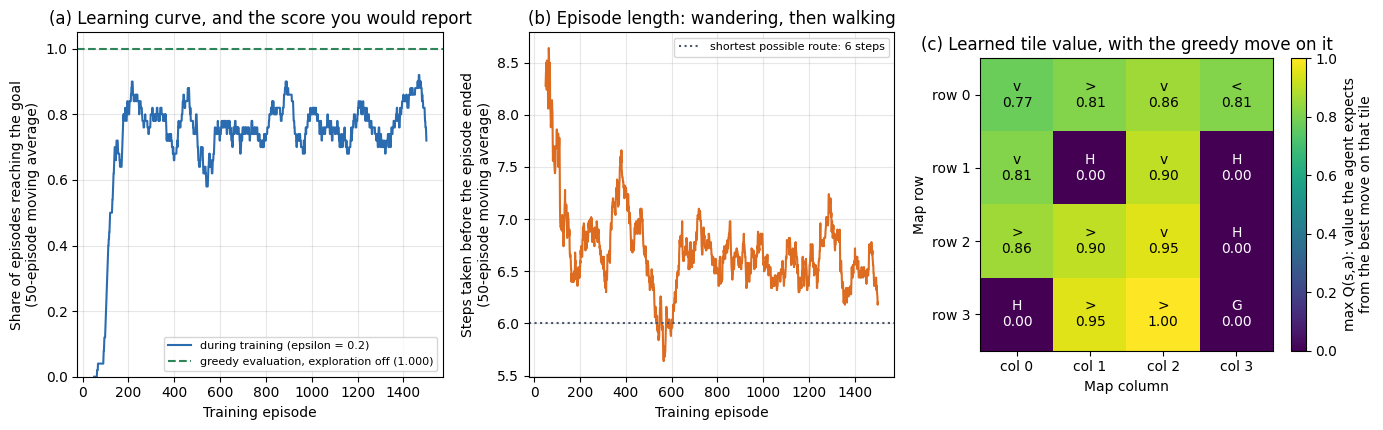


Learned greedy policy (holes and goal shown as H / G):
    v  >  v  < 
    v  H  v  H 
    >  >  v  H 
    H  >  >  G 

Reminder: the reward is 1.0 only at the goal, so a high Q-value on a tile means
'a path to the goal runs through here', not 'this tile pays'.

Stretch task: PREDICT first, then measure. Write down what you expect to happen to
the greedy success rate above if you rebuild the environment with is_slippery=True
(the ice then makes your chosen action succeed only about a third of the time).
Now actually do it: change the gym.make(...) line in Task 1, restart and rerun the
notebook, and compare your prediction with the number this cell prints. If they
disagree, the gap between them is the most useful thing in this exercise.


In [3]:
# Task 3 worked example: train the agent, then EVALUATE it with exploration switched off.
# WHY it matters: the training curve records an agent that is still exploring on purpose. The score
# a user would experience is the greedy one. Reporting only the training curve is the most common
# way RL results get overstated - by students and by papers alike.

N_EPISODES, STEP_CAP = 1500, 100
agent = QLearningAgent(n_states, n_actions, alpha=0.5, gamma=0.95, epsilon=0.2, seed=42)

episode_rewards, episode_steps = [], []
for episode in range(N_EPISODES):
    state, _ = env.reset(seed=episode)
    total_reward, steps = 0.0, STEP_CAP
    for step_idx in range(STEP_CAP):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        agent.update(state, action, reward, next_state, terminated)
        state = next_state
        total_reward += reward
        if terminated or truncated:
            steps = step_idx + 1
            break
    episode_rewards.append(total_reward)
    episode_steps.append(steps)

episode_rewards = np.array(episode_rewards)
print(f"Success rate, first 100 episodes : {episode_rewards[:100].mean():.3f}")
print(f"Success rate, last 100 episodes  : {episode_rewards[-100:].mean():.3f}")


def evaluate_greedy(agent, n_episodes=500):
    """Run the greedy policy (epsilon = 0) and report success rate and mean steps to the goal."""
    wins, step_counts = 0.0, []
    for i in range(n_episodes):
        state, _ = env.reset(seed=5000 + i)
        for step_idx in range(STEP_CAP):
            state, reward, terminated, truncated, _ = env.step(int(np.argmax(agent.q[state])))
            if terminated or truncated:
                wins += reward
                if reward > 0:
                    step_counts.append(step_idx + 1)
                break
    return wins / n_episodes, (float(np.mean(step_counts)) if step_counts else float("nan"))


success, mean_steps = evaluate_greedy(agent)
print(f"\nGreedy evaluation on 500 fresh episodes: success rate {success:.3f}, "
      f"mean steps when it wins {mean_steps:.1f}")
print("The shortest possible route on this map is 6 steps.")

ARROWS = {0: "<", 1: "v", 2: ">", 3: "^"}   # action id -> a one-character direction

# One figure, three panels: what training looked like, how long episodes ran, and what was learned.
window = 50
smoothed_success = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
smoothed_steps = np.convolve(episode_steps, np.ones(window) / window, mode="valid")
episode_axis = np.arange(window, N_EPISODES + 1)   # a moving average is only defined from episode 50 on

fig, (ax_success, ax_steps, ax_values) = plt.subplots(1, 3, figsize=(14.0, 4.4))

# --- (a) did it learn? training score vs the score you would actually ship ---
ax_success.plot(episode_axis, smoothed_success, color="#2b6cb0", label=f"during training (epsilon = {agent.epsilon})")
# The greedy score is a DIFFERENT measurement, so it is drawn as a reference line, not as part of the curve.
ax_success.axhline(success, color="#2f855a", linestyle="--",
                   label=f"greedy evaluation, exploration off ({success:.3f})")
ax_success.set_xlabel("Training episode")
ax_success.set_ylabel(f"Share of episodes reaching the goal\n({window}-episode moving average)")
ax_success.set_title("(a) Learning curve, and the score you would report")
ax_success.set_ylim(0, 1.05)
ax_success.legend(loc="lower right", fontsize=8)
ax_success.grid(alpha=0.3)

# --- (b) episodes get shorter as the agent stops wandering ---
ax_steps.plot(episode_axis, smoothed_steps, color="#dd6b20")
# 6 is the shortest legal route from S to G. Note this is NOT a floor for the curve: an episode
# that ends early in a hole is shorter than 6 steps, so a falling average can also mean failure.
ax_steps.axhline(6, color="#4a5568", linestyle=":", label="shortest possible route: 6 steps")
ax_steps.set_xlabel("Training episode")
ax_steps.set_ylabel(f"Steps taken before the episode ended\n({window}-episode moving average)")
ax_steps.set_title("(b) Episode length: wandering, then walking")
ax_steps.legend(loc="upper right", fontsize=8)
ax_steps.grid(alpha=0.3)

# --- (c) the learned value of each tile, drawn on the map itself ---
tile_values = agent.q.max(axis=1).reshape(4, 4)
heat = ax_values.imshow(tile_values, cmap="viridis")
for row in range(4):
    for col in range(4):
        s = row * 4 + col
        tile = layout[row][col]
        # Holes and the goal are terminal: the agent never chooses an action there, so no arrow.
        mark = tile if tile in ("H", "G") else ARROWS[int(np.argmax(agent.q[s]))]
        ink = "black" if tile_values[row, col] > tile_values.max() * 0.55 else "white"
        ax_values.text(col, row, f"{mark}\n{tile_values[row, col]:.2f}",
                       ha="center", va="center", color=ink, fontsize=10)
ax_values.set_xticks(range(4), labels=[f"col {c}" for c in range(4)])
ax_values.set_yticks(range(4), labels=[f"row {r}" for r in range(4)])
ax_values.set_xlabel("Map column")
ax_values.set_ylabel("Map row")
ax_values.set_title("(c) Learned tile value, with the greedy move on it")
value_bar = fig.colorbar(heat, ax=ax_values, shrink=0.85)
value_bar.set_label("max Q(s,a): value the agent expects\nfrom the best move on that tile")

fig.tight_layout()
plt.show()

print("\nLearned greedy policy (holes and goal shown as H / G):")
for row in range(4):
    cells = []
    for col in range(4):
        s = row * 4 + col
        tile = layout[row][col]
        cells.append(f" {tile} " if tile in ("H", "G") else f" {ARROWS[int(np.argmax(agent.q[s]))]} ")
    print("   " + "".join(cells))
print("\nReminder: the reward is 1.0 only at the goal, so a high Q-value on a tile means")
print("'a path to the goal runs through here', not 'this tile pays'.")
print("\nStretch task: PREDICT first, then measure. Write down what you expect to happen to")
print("the greedy success rate above if you rebuild the environment with is_slippery=True")
print("(the ice then makes your chosen action succeed only about a third of the time).")
print("Now actually do it: change the gym.make(...) line in Task 1, restart and rerun the")
print("notebook, and compare your prediction with the number this cell prints. If they")
print("disagree, the gap between them is the most useful thing in this exercise.")

### 👁️ Read the figure

- **(a) is the whole point of Task 3, in one picture.** The blue curve is the agent *while it is still exploring*: it climbs from near zero to roughly 0.8 and then stops climbing. The green dashed line is the same agent measured with epsilon set to 0 — it sits at **1.000**. The gap between the two lines is not a bug and it is not learning that has not finished; it is the 20% of moves that epsilon-greedy takes at random, some of which walk into a hole. Report the green number as the agent's score, and the blue curve as the record of how it got there.
- **The blue curve starts at episode 50, not episode 0.** A 50-episode moving average has nothing to average before then. The first printed number (success rate 0.080 over the first 100 episodes) is what the very beginning looks like: almost every early episode ends in a hole.
- **(b) says the agent stopped wandering — but read the dotted line carefully.** Early episodes average about 8.5 steps; as the Q-values sharpen the average settles just above the dotted line at 6, the shortest legal route from S to G. The dotted line is **not a floor**: around episode 550 the average dips to roughly 5.7, which is *shorter* than the shortest winning route. That can only mean episodes ending early — in a hole. A short episode is not automatically a good episode, which is exactly why panel (b) must be read next to panel (a) and never on its own. The greedy evaluation prints **mean steps 6.0**, so the policy you would actually deploy walks the optimal route with no detour.
- **(c) is where the sparse reward becomes visible, and where γ is written on the map.** Only the goal tile ever pays 1.0, so every non-zero number here arrived by being propagated backwards. Follow the greedy characters from the start tile — down, down, right, right, down, right — and read the values along that chain: **1.00, 0.95, 0.90, 0.86, 0.81, 0.77**. Each step away from the goal multiplies the value by γ = 0.95, so the map is a picture of discounting, and 0.77 on the start tile is 0.95⁵. The four `H` tiles stay dark at 0.00: falling in ends the episode with nothing, so nothing is ever backed up out of them.
- **A dark tile is not always a bad tile.** The goal `G` shows a low value for the same reason as any terminal state: nothing is ever backed up *out of* it. What makes the route good is the value on the tiles *leading into* it.


In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can apply classical RL updates independently rather than only recognizing them in notes.

**If students remember one idea:** Real understanding appears when a student can explain why an update changed, not just compute it mechanically.

**Quick check before moving on:**
- Can you justify each update in your own words?
- Can you explain how your exploration choice influenced the learned values?

**Bridge to the next step:** After this exercise, students are ready to move from tabular methods toward deep RL representations.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=6 | term=True | trunc=False


objc[56632]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101b4138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106b09c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[56632]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101b4188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106b0a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[56632]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101b3c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106b0a68). T

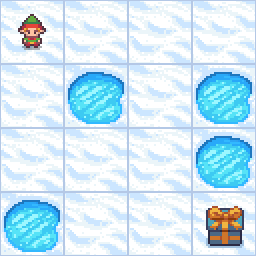

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
